In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from yellowbrick.classifier import ConfusionMatrix


In [3]:

# Load dataset
dataset = pd.read_csv("2_letter_recognition.data", sep=",")

# Features and target
X = dataset.iloc[:, 1:17]
Y = dataset.select_dtypes(include=[object])

print("Dataset Loaded Successfully")
print(dataset.head())


Dataset Loaded Successfully
   T  2   8  3  5  1  8.1  13  0  6  6.1  10  8.2  0.1  8.3  0.2  8.4
0  I  5  12  3  7  2   10   5  5  4   13   3    9    2    8    4   10
1  D  4  11  6  8  6   10   6  2  6   10   3    7    3    7    3    9
2  N  7  11  6  6  3    5   9  4  6    4   4   10    6   10    2    8
3  G  2   1  3  1  1    8   6  6  6    6   5    9    1    7    5   10
4  S  4  11  5  8  3    8   8  6  9    5   6    6    0    8    9    7


In [4]:

# Split dataset
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=10
)

print("Shape of X_train:", X_train.shape)
print("Shape of Y_train:", Y_train.shape)


Shape of X_train: (15999, 16)
Shape of Y_train: (15999, 1)


In [5]:

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_validation = scaler.transform(X_validation)

print("Data Scaling Completed")


Data Scaling Completed


In [6]:

# Create MLP Classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    max_iter=200,
    activation='relu',
    random_state=42
)

# Train model
mlp.fit(X_train, Y_train.values.ravel())

print("Model Training Completed")


Model Training Completed


Accuracy: 0.969


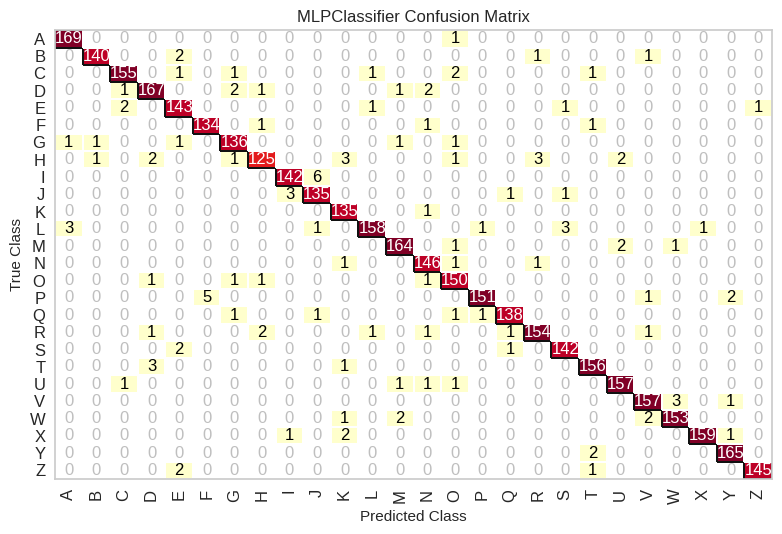

<Axes: title={'center': 'MLPClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [7]:

# Create Confusion Matrix Visualizer
cm = ConfusionMatrix(
    mlp,
    classes=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
)

# Fit visualizer
cm.fit(X_train, Y_train.values.ravel())

# Evaluate model
cm.score(X_validation, Y_validation.values.ravel())

# Predictions
predictions = mlp.predict(X_validation)

# Accuracy
print("Accuracy:", accuracy_score(Y_validation.values.ravel(), predictions))

# Display confusion matrix
cm.show()


In [8]:

# Check missing values
print("Missing values in X_train:")
print(pd.DataFrame(X_train).isnull().sum())

print("\nMissing values in Y_train:")
print(Y_train.isnull().sum())


Missing values in X_train:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
dtype: int64

Missing values in Y_train:
T    0
dtype: int64
